In [2]:
pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 10.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
opencv-python-h

In [ ]:
!pip install --force-reinstall numpy
!pip install --force-reinstall gensim

^C


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import numpy as np

# Load preprocessed data
input_file = "preprocessed_data.csv"
df = pd.read_csv(input_file)

# Drop rows with missing values in 'cleaned_text' column
df = df.dropna(subset=['cleaned_text'])

# Vectorize the text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=15, random_state=42)  # Extract 15 topics
topic_distribution = lda.fit_transform(X)

# Print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

# Assign the dominant topic to each document
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Convert sklearn's LDA output to gensim-compatible format
# Step 1: Tokenize the cleaned text
texts = df['cleaned_text'].apply(lambda x: x.split()).tolist()

# Step 2: Create a gensim dictionary and corpus
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Step 3: Reconstruct topic-word distribution from sklearn's LDA
topic_word_distributions = []
for topic_idx, topic in enumerate(lda.components_):
    # Normalize the topic distribution
    normalized_topic = topic / topic.sum()
    # Map sklearn's feature indices to gensim's dictionary indices
    topic_words = [(dictionary.token2id[vectorizer.get_feature_names_out()[i]], prob)
                  for i, prob in enumerate(normalized_topic) if vectorizer.get_feature_names_out()[i] in dictionary.token2id]
    # Only add topics with at least one word
    if topic_words:
        topic_word_distributions.append(topic_words)

# Step 4: Compute coherence score
coherence_model = CoherenceModel(
    topics=[[word_id for word_id, _ in topic] for topic in topic_word_distributions],
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()

print(f"Coherence Score: {coherence_score}")

Topic #0:
ai prompt user model chatgpt like language product code engineering
Topic #1:
prompt chatgpt use im like gpt chat using ive question
Topic #2:
model chatgpt ai like code use llm voice size time
Topic #3:
model llm new chatgpt data context image human learning reasoning
Topic #4:
ai llm gpt model using context cipher ive da chatgpt
Topic #5:
user use ai prompt information chatgpt question response rating provide
Topic #6:
ai chatgpt model like openai use using help im data
Topic #7:
chatgpt openai ai like data using say image prompt im
Topic #8:
chatgpt ai consciousness quantum thought like paper image gpt im
Topic #9:
model story llm use using chatgpt like gpt approach time
Topic #10:
ai chatgpt like human people solution think time problem tool
Topic #11:
ai like response chatgpt message script video banquet im need
Topic #12:
ai chatgpt model prompt like use work content new data
Topic #13:
im chatgpt ai like llm prompt model time box game
Topic #14:
ai like llm model human

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import numpy as np

# Load preprocessed data
input_file = "preprocessed_data.csv"
df = pd.read_csv(input_file)

# Drop rows with missing values in 'cleaned_text' column
df = df.dropna(subset=['cleaned_text'])

# Vectorize the text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)  # Extract 15 topics
topic_distribution = lda.fit_transform(X)

# Print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

# Assign the dominant topic to each document
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Convert sklearn's LDA output to gensim-compatible format
# Step 1: Tokenize the cleaned text
texts = df['cleaned_text'].apply(lambda x: x.split()).tolist()

# Step 2: Create a gensim dictionary and corpus
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Step 3: Reconstruct topic-word distribution from sklearn's LDA
topic_word_distributions = []
for topic_idx, topic in enumerate(lda.components_):
    # Normalize the topic distribution
    normalized_topic = topic / topic.sum()
    # Map sklearn's feature indices to gensim's dictionary indices
    topic_words = [(dictionary.token2id[vectorizer.get_feature_names_out()[i]], prob)
                  for i, prob in enumerate(normalized_topic) if vectorizer.get_feature_names_out()[i] in dictionary.token2id]
    # Only add topics with at least one word
    if topic_words:
        topic_word_distributions.append(topic_words)

# Step 4: Compute coherence score
coherence_model = CoherenceModel(
    topics=[[word_id for word_id, _ in topic] for topic in topic_word_distributions],
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()

print(f"Coherence Score: {coherence_score}")

Topic #0:
ai prompt model chatgpt like image new time click user
Topic #1:
prompt chatgpt im use like gpt llm using chat want
Topic #2:
model chatgpt code like ai llm know data size use
Topic #3:
model llm human ai data new like solution problem reasoning
Topic #4:
ai model llm gpt like chatgpt response context using ive
Topic #5:
user ai prompt use response information need interaction feedback core
Topic #6:
ai chatgpt model openai like people data use tool new
Topic #7:
ai chatgpt like data image im piece using game prompt
Topic #8:
ai chatgpt like consciousness thought experience im quantum human news
Topic #9:
model story llm using use chatgpt like time approach better
Coherence Score: 0.7146169611333602


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import numpy as np

# Load preprocessed data
input_file = "preprocessed_data.csv"
df = pd.read_csv(input_file)

# Drop rows with missing values in 'cleaned_text' column
df = df.dropna(subset=['cleaned_text'])

# Vectorize the text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # Extract 15 topics
topic_distribution = lda.fit_transform(X)

# Print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

# Assign the dominant topic to each document
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Convert sklearn's LDA output to gensim-compatible format
# Step 1: Tokenize the cleaned text
texts = df['cleaned_text'].apply(lambda x: x.split()).tolist()

# Step 2: Create a gensim dictionary and corpus
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Step 3: Reconstruct topic-word distribution from sklearn's LDA
topic_word_distributions = []
for topic_idx, topic in enumerate(lda.components_):
    # Normalize the topic distribution
    normalized_topic = topic / topic.sum()
    # Map sklearn's feature indices to gensim's dictionary indices
    topic_words = [(dictionary.token2id[vectorizer.get_feature_names_out()[i]], prob)
                  for i, prob in enumerate(normalized_topic) if vectorizer.get_feature_names_out()[i] in dictionary.token2id]
    # Only add topics with at least one word
    if topic_words:
        topic_word_distributions.append(topic_words)

# Step 4: Compute coherence score
coherence_model = CoherenceModel(
    topics=[[word_id for word_id, _ in topic] for topic in topic_word_distributions],
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()

print(f"Coherence Score: {coherence_score}")

Topic #0:
ai chatgpt like prompt user model image new time tool
Topic #1:
prompt chatgpt use im like using ai llm gpt help
Topic #2:
chatgpt model like ai code time im know use data
Topic #3:
model ai llm chatgpt human data new like openai problem
Topic #4:
ai model chatgpt like llm gpt using use im context
Coherence Score: 0.7146169611333602


In [ ]:
#BERTopic
!pip install bertopic pandas scikit-learn nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 844.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
!pip install matplotlib umap-learn

In [ ]:
from pprint import pprint

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# ----------------------------
# Step 1: Load the dataset
# ----------------------------
input_file = "preprocessed_data.csv"
df = pd.read_csv(input_file)

# Assume your cleaned text is in a column called 'cleaned_text'
text_column = 'merged_text'  # Replace with actual column name if different

# Optional: Reduce noise further using CountVectorizer
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words="english")

# ----------------------------
# Step 2: Train BERTopic model
# ----------------------------

# Initialize model
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    nr_topics=10,          # Automatically reduce to meaningful number of topics
    verbose=True
)

# Fit the model
documents = df[text_column].astype(str).tolist()
topics, probs = topic_model.fit_transform(documents)

# ----------------------------
# Step 3: Get and Display Topics
# ----------------------------

# Show top topics
print("Top Topics:")
print(topic_model.get_topic_info())

# Print keywords for each topic
print("\nTopic Keywords:")
for topic_id in sorted(set(topics)):
    print(f"\nTopic #{topic_id}:")
    pprint(topic_model.get_topic(topic_id))

# ----------------------------
# Step 4: Add Topics Back to DataFrame
# ----------------------------

# Get topics and their most representative term
df['topic_id'] = topics

# Assign a short name to each topic using its top word
df['topic_name'] = [topic_model.get_topic(tid)[0][0] if tid != -1 else "Outliers" for tid in topics]

# Save updated DataFrame
output_file = "bertopic_results.csv"
df.to_csv(output_file, index=False)
print(f"\nResults saved to {output_file}")


2025-07-08 16:18:29,951 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/793 [00:00<?, ?it/s]

2025-07-08 16:50:46,884 - BERTopic - Embedding - Completed ✓
2025-07-08 16:50:46,890 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-08 16:52:12,453 - BERTopic - Dimensionality - Completed ✓
2025-07-08 16:52:12,455 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-08 16:52:21,686 - BERTopic - Cluster - Completed ✓
2025-07-08 16:52:21,687 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-07-08 16:52:28,259 - BERTopic - Representation - Completed ✓
2025-07-08 16:52:28,264 - BERTopic - Topic reduction - Reducing number of topics
2025-07-08 16:52:28,463 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-08 16:52:36,730 - BERTopic - Representation - Completed ✓
2025-07-08 16:52:36,740 - BERTopic - Topic reduction - Reduced number of topics from 1165 to 10


Top Topics:
   Topic  Count                                               Name  \
0      0  24713                             0_ai_chatgpt_like_just   
1      1    149                       1_density_data_class_spatial   
2      2     85                     2_yes_region_reasoning_regions   
3      3     85                        3_reicha_music_works_period   
4      4     64      4_death_faithfull_marianne_marianne faithfull   
5      5     63                       5_foam_dimensions_qty_prisms   
6      6     63              6_save_messages_lower save_code lower   
7      7     63  7_damn clue_contradictions spits_obviously rig...   
8      8     42                   8_nahh wild_nahh_istg didnt_istg   
9      9     22        9_metrics_analysis_socioeconomic_governance   

                                      Representation  \
0  [ai, chatgpt, like, just, use, prompt, model, ...   
1  [density, data, class, spatial, model, shifts,...   
2  [yes, region, reasoning, regions, hidden, acti

Python Code: Measure Topic Coherence from bertopic_results.csv

In [ ]:
pip install pandas gensim scikit-learn

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# ----------------------------
# Step 1: Load the BERTopic results CSV
# ----------------------------
input_file = "bertopic_results.csv"
df = pd.read_csv(input_file)

# Replace with actual column names in your CSV
text_column = "merged_text"     # Column containing raw or cleaned text
topic_column = "topic_id"       # Column containing topic assignments

# Optional: Clean up any missing values
df[text_column] = df[text_column].fillna("")
documents = df[text_column].astype(str).tolist()
topics = df[topic_column].astype(int).tolist()

# ----------------------------
# Step 2: Prepare corpus for Gensim
# ----------------------------

# Tokenize each document
texts = [doc.split() for doc in documents]

# Create Gensim dictionary and corpus
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Get unique topics (excluding outliers like -1 if desired)
unique_topics = sorted(set(topics))
print(f"Unique Topics Found: {len(unique_topics)}")

# ----------------------------
# Step 3: Extract top words per topic from BERTopic
# ----------------------------

# Recreate topic-word distributions using c-TF-IDF weights
vectorizer = CountVectorizer().fit(documents)
vocabulary = vectorizer.get_feature_names_out()

# Get word counts per topic
topic_word_counts = {}

for topic_id in unique_topics:
    if topic_id == -1:
        continue  # Skip outliers
    topic_docs = [documents[i] for i, tid in enumerate(topics) if tid == topic_id]
    bag_of_words = vectorizer.transform(topic_docs)
    word_scores = bag_of_words.sum(axis=0).A1
    top_indices = word_scores.argsort()[::-1][:10]  # Top 10 words per topic
    topic_words = [vocabulary[i] for i in top_indices]
    topic_word_counts[topic_id] = topic_words

# Convert to list of lists for coherence model
topic_words_list = [topic_words for tid, topic_words in sorted(topic_word_counts.items())]

# ----------------------------
# Step 4: Compute Coherence Score
# ----------------------------

coherence_model = CoherenceModel(
    topics=topic_words_list,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print(f"\nCoherence Score (c_v): {coherence_score:.4f}")

Unique Topics Found: 10

Coherence Score (c_v): 0.3822


In [ ]:
topic_model.visualize_topics().show()         # Intertopic distance map
topic_model.visualize_barchart(top_n_topics=10)  # Topic word scores
topic_model.visualize_term_rank()            # Term rank decay

Topic distribution analysis across documents

Visualization of topic prevalence using a bar chart

Topic #0:
ai prompt model chatgpt like image new time click user
Topic #1:
prompt chatgpt im use like gpt llm using chat want
Topic #2:
model chatgpt code like ai llm know data size use
Topic #3:
model llm human ai data new like solution problem reasoning
Topic #4:
ai model llm gpt like chatgpt response context using ive
Topic #5:
user ai prompt use response information need interaction feedback core
Topic #6:
ai chatgpt model openai like people data use tool new
Topic #7:
ai chatgpt like data image im piece using game prompt
Topic #8:
ai chatgpt like consciousness thought experience im quantum human news
Topic #9:
model story llm using use chatgpt like time approach better


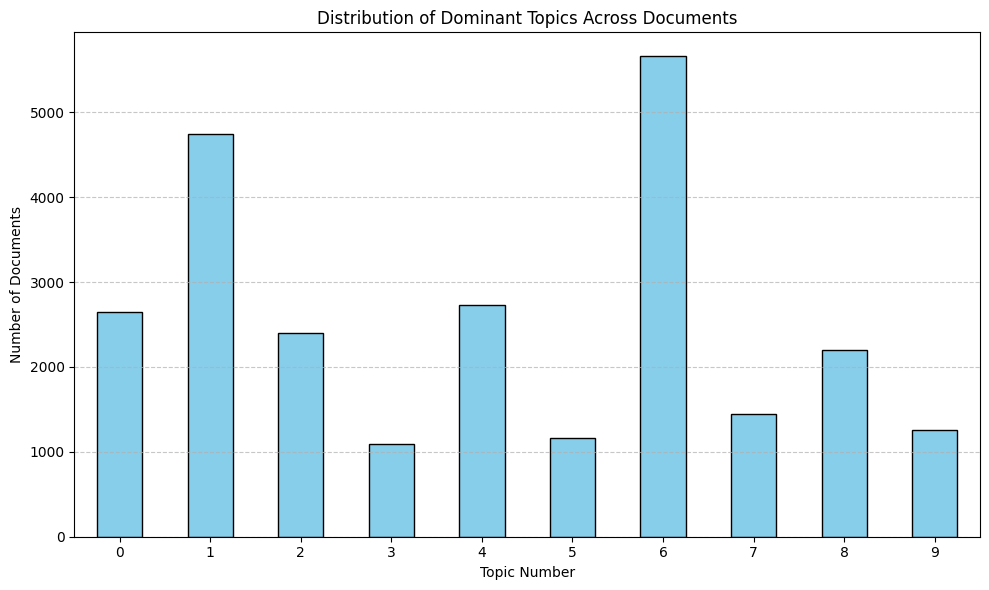

Coherence Score: 0.7146169611333602


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import numpy as np
import matplotlib.pyplot as plt

# Load preprocessed data
input_file = "preprocessed_data.csv"
df = pd.read_csv(input_file)

# Drop rows with missing values in 'cleaned_text' column
df = df.dropna(subset=['cleaned_text'])

# Vectorize the text data
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])

# Apply LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)  # Using 10 topics
topic_distribution = lda.fit_transform(X)

# Print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

# Assign the dominant topic to each document
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Analyze topic distribution across documents
topic_counts = df['dominant_topic'].value_counts().sort_index()

# Plot topic distribution
plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Dominant Topics Across Documents')
plt.xlabel('Topic Number')
plt.ylabel('Number of Documents')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('topic_distribution.png')  # Save plot to file
plt.show()

# Convert sklearn's LDA output to gensim-compatible format
# Step 1: Tokenize the cleaned text
texts = df['cleaned_text'].apply(lambda x: x.split()).tolist()

# Step 2: Create a gensim dictionary and corpus
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Step 3: Reconstruct topic-word distribution from sklearn's LDA
topic_word_distributions = []
for topic_idx, topic in enumerate(lda.components_):
    # Normalize the topic distribution
    normalized_topic = topic / topic.sum()
    # Map sklearn's feature indices to gensim's dictionary indices
    topic_words = [(dictionary.token2id[vectorizer.get_feature_names_out()[i]], prob)
                   for i, prob in enumerate(normalized_topic)
                   if vectorizer.get_feature_names_out()[i] in dictionary.token2id]
    # Only add topics with at least one word
    if topic_words:
        topic_word_distributions.append(topic_words)

# Step 4: Compute coherence score
coherence_model = CoherenceModel(
    topics=[[word_id for word_id, _ in topic] for topic in topic_word_distributions],
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()

print(f"Coherence Score: {coherence_score}")

In [2]:
# Print number of documents per topic
print("Number of documents per topic:")
print(topic_counts)

# Print with percentages
total_docs = len(df)
topic_percentages = (topic_counts / total_docs) * 100

print("\nTopic distribution with percentages:")
for topic_id, count in topic_counts.items():
    print(f"Topic #{topic_id}: {count} documents ({topic_percentages[topic_id]:.2f}%)")

# Export to CSV
topic_counts_df = pd.DataFrame({
    'Topic': topic_counts.index,
    'Document Count': topic_counts.values,
    'Percentage (%)': (topic_counts.values / total_docs) * 100
})
topic_counts_df.to_csv('topic_distribution.csv', index=False)
print("\nSaved topic distribution to 'topic_distribution.csv'")

Number of documents per topic:
dominant_topic
0    2651
1    4748
2    2397
3    1092
4    2734
5    1158
6    5660
7    1446
8    2203
9    1260
Name: count, dtype: int64

Topic distribution with percentages:
Topic #0: 2651 documents (10.46%)
Topic #1: 4748 documents (18.73%)
Topic #2: 2397 documents (9.46%)
Topic #3: 1092 documents (4.31%)
Topic #4: 2734 documents (10.79%)
Topic #5: 1158 documents (4.57%)
Topic #6: 5660 documents (22.33%)
Topic #7: 1446 documents (5.70%)
Topic #8: 2203 documents (8.69%)
Topic #9: 1260 documents (4.97%)

Saved topic distribution to 'topic_distribution.csv'
